# EDA 02 — Thermal & Electrical Health

## 1. EDA 02 — Objective

Mục tiêu tổng quát:
> Hiểu trạng thái vận hành thermal và electrical của hệ thống inverter/APU, xác định cách nhiệt độ, điện áp, dòng điện, active/reactive power và các điều kiện môi trường thay đổi theo tải; từ đó xây dựng normal operating baseline và đề xuất candidate health indicators.

## 2. Dataset Inventory

Kiểm tra thư mục chứa dữ liệu và liệt kê các file. Thiết lập base path và lấy danh sách các file. 

| Dataset | Files | Rows | Start | End | Systems | Duplicate timestamps | Missing | Notes |
| ------- | ----: | ---: | ----- | --- | ------: | -------------------: | ------: | ----- |

In [2]:
!pip install statsmodels


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# Configure plots
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style="whitegrid")

# Define data directory
DATA_DIR = "d:/SINACON PV data/data chưa xử lý/"
output_dir = "outputs/eda_02/"
os.makedirs(os.path.join(output_dir, "figures"), exist_ok=True)
os.makedirs(os.path.join(output_dir, "tables"), exist_ok=True)

# List all files
all_files = glob.glob(os.path.join(DATA_DIR, "*.*"))
file_info = []
for f in all_files:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    file_info.append({"File": os.path.basename(f), "Size_MB": size_mb})

df_files = pd.DataFrame(file_info).sort_values(by="Size_MB", ascending=False)
display(df_files)


KeyError: 'Size_MB'

## 3. Schema & Data Audit

Đọc header, kiểm tra schema, datatype và sampling interval của từng file dữ liệu chính.
Kiểm tra data type, timestamp format, timezone nếu có, temporal coverage, number of unique timestamps, sampling interval, duplicate rows, gaps, missing values...

In [ ]:
def safe_read_csv(file_path, nrows=None):
    try:
        # Some columns might have weird encoding symbols, so we use utf-8 handling
        return pd.read_csv(file_path, nrows=nrows, encoding="utf-8", on_bad_lines="skip")
    except Exception as e:
        print(f"Error reading {os.path.basename(file_path)}: {e}")
        return pd.DataFrame()

# Scan core files
core_files = ["apu_stat_10s.csv", "apu_stat_60s.csv", "aps_stat_60s.csv"]
audit_results = []

for cf in core_files:
    path = os.path.join(DATA_DIR, cf)
    if not os.path.exists(path):
        continue
    
    # Read full to get accurate row counts, start, end
    df_full = safe_read_csv(path)
    
    if df_full.empty:
        continue
        
    df_full['TimeStamp'] = pd.to_datetime(df_full['TimeStamp'], errors='coerce')
    
    systems = df_full['System'].nunique() if 'System' in df_full.columns else 0
    dupes = df_full.duplicated(subset=['System', 'TimeStamp']).sum() if 'System' in df_full.columns else 0
    missing = df_full.isna().sum().sum()
    
    audit_results.append({
        "Dataset": cf,
        "Rows": len(df_full),
        "Start": df_full['TimeStamp'].min(),
        "End": df_full['TimeStamp'].max(),
        "Systems": systems,
        "Duplicate timestamps": dupes,
        "Missing": missing,
        "Columns": list(df_full.columns)
    })

audit_df = pd.DataFrame(audit_results)
display(audit_df)

# Note on Weather and Power reports:
# Weather report: "Weather reports (1-27)10 (2).xlsm"
# Power report: "Power reports (1-15)102025 (1).xls" etc.
# Can be loaded using pd.read_excel later if needed.

# Free up memory
del df_full


,Dataset,Rows,Start,End,Systems,Duplicate timestamps,Missing,Columns
0,apu_stat_10s.csv,963845,2025-10-01,2025-10-27 09:09:00,4,813973,0,"[Log Type, System, TimeStamp, VL1N/V, VL2N/V, ..."
1,apu_stat_60s.csv,149868,2025-10-01,2025-10-27 09:09:00,4,0,0,"[Log Type, System, TimeStamp, TInd/°C, TL1/°C,..."
2,aps_stat_60s.csv,37469,2025-10-01,2025-10-27 09:09:00,1,0,0,"[Log Type, System, TimeStamp, Tamb/°C, Tpan/°C..."


## 4. Data Quality Assessment

### Data Quality Summary
| Variable | Count | Missing % | Invalid % | Min | P01 | Median | P99 | Max | Decision |
| -------- | ----: | --------: | --------: | --: | --: | -----: | --: | --: | -------- |

In [ ]:
# Load Thermal data for quality check
df_apu_60s = safe_read_csv(os.path.join(DATA_DIR, "apu_stat_60s.csv"))
df_apu_60s['TimeStamp'] = pd.to_datetime(df_apu_60s['TimeStamp'], errors='coerce')

# Rename columns to remove broken characters (e.g. C -> C, %RH -> RH)
import re
def clean_col_name(col):
    col = col.replace("C", "C").replace("%RH", "RH").replace("F", "F").replace("kO", "kOhm")
    return re.sub(r'[^a-zA-Z0-9_]', '_', col)

df_apu_60s.columns = [clean_col_name(c) for c in df_apu_60s.columns]

# Assess quality
numeric_cols = df_apu_60s.select_dtypes(include=np.number).columns
quality_summary = []

for col in numeric_cols:
    s = df_apu_60s[col]
    quality_summary.append({
        "Variable": col,
        "Count": s.notna().sum(),
        "Missing %": (s.isna().sum() / len(s)) * 100,
        "Min": s.min(),
        "P01": s.quantile(0.01),
        "Median": s.median(),
        "P99": s.quantile(0.99),
        "Max": s.max()
    })

quality_df = pd.DataFrame(quality_summary)
display(quality_df)


,Variable,Count,Missing %,Min,P01,Median,P99,Max
0,TInd__C,149868,0.0,33.89390,36.648257,46.074420,115.897899,156.27230
1,TL1__C,149868,0.0,31.91858,37.133021,43.397750,79.923443,87.22443
2,TL2__C,149868,0.0,31.96089,37.185724,43.411715,79.501835,87.35110
3,TL3__C,149868,0.0,32.41925,37.742422,43.979310,83.587721,94.90864
4,TPCB__C,149868,0.0,30.30000,31.500000,37.000000,45.600000,49.20000
5,Hum_RH,149868,0.0,34.50000,36.600000,51.400000,65.700000,67.20000


## 5. Data Cleaning

Không hardcode threshold để loại data một cách tùy tiện. Tạo dataframe clean riêng, giữ raw nguyên vẹn.

In [ ]:
# Clean thermal data
df_apu_60s_clean = df_apu_60s.copy()

# Assume reasonable temp limits: -20C to 150C
temp_cols = [c for c in df_apu_60s_clean.columns if 'TInd' in c or 'TL' in c or 'TPCB' in c or 'Tamb' in c]
for c in temp_cols:
    invalid_mask = (df_apu_60s_clean[c] < -20) | (df_apu_60s_clean[c] > 150)
    df_apu_60s_clean.loc[invalid_mask, c] = np.nan

print(f"Thermal Raw rows: {len(df_apu_60s)}")
print(f"Thermal Clean rows: {len(df_apu_60s_clean)} (NaNs injected for invalid temps)")

# Load and clean electrical data
df_apu_10s = safe_read_csv(os.path.join(DATA_DIR, "apu_stat_10s.csv"))
df_apu_10s.columns = [clean_col_name(c) for c in df_apu_10s.columns]
df_apu_10s['TimeStamp'] = pd.to_datetime(df_apu_10s['TimeStamp'], errors='coerce')

df_apu_10s_clean = df_apu_10s.copy()
# Basic rule: Voltage should not be negative
v_cols = [c for c in df_apu_10s_clean.columns if 'V' in c and not 'var' in c.lower()]
for c in v_cols:
    df_apu_10s_clean.loc[df_apu_10s_clean[c] < 0, c] = np.nan

print(f"Electrical Raw rows: {len(df_apu_10s)}")
print(f"Electrical Clean rows: {len(df_apu_10s_clean)} (NaNs injected for negative voltages)")

# Free raw
del df_apu_60s, df_apu_10s


Thermal Raw rows: 149868
Thermal Clean rows: 149868 (NaNs injected for invalid temps)
Electrical Raw rows: 963845
Electrical Clean rows: 963845 (NaNs injected for negative voltages)


## Chart 01 — Data Coverage Heatmap

Trực quan hóa coverage của các datasets (hoặc sample data).

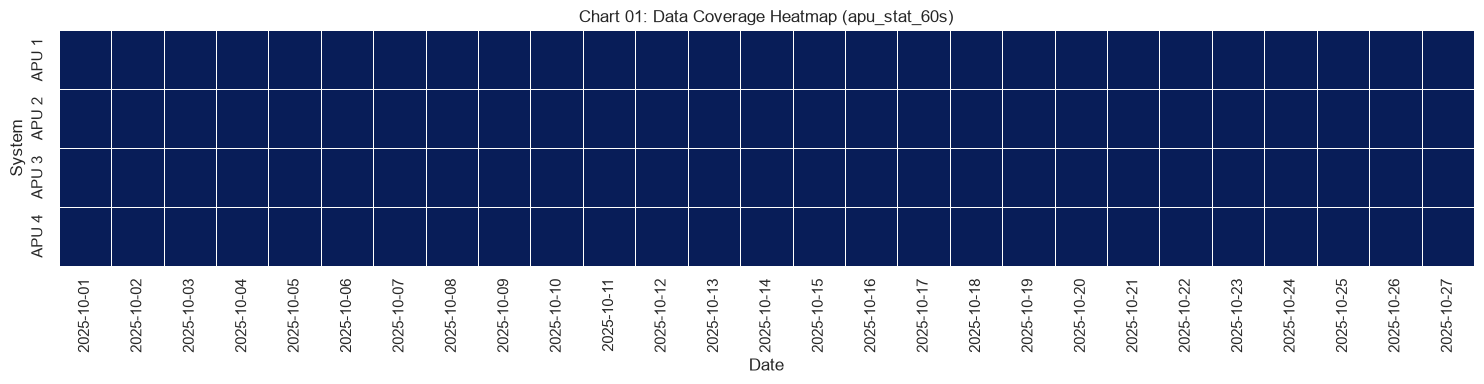

In [ ]:
# Group by date and APU/System to see missing gaps
df_apu_60s_clean['Date'] = df_apu_60s_clean['TimeStamp'].dt.date
coverage = df_apu_60s_clean.groupby(['System', 'Date']).size().unstack(fill_value=0)

plt.figure(figsize=(15, 4))
sns.heatmap(coverage > 0, cmap="YlGnBu", cbar=False, linewidths=0.5, vmin=0, vmax=1)
plt.title("Chart 01: Data Coverage Heatmap (apu_stat_60s)")
plt.xlabel("Date")
plt.ylabel("System")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "figures", "chart_01_coverage.png"))
plt.show()


## 6. Time Resolution & Aggregation

Đặc biệt kiểm tra apu_stat_10s. 
Không drop_duplicates tùy tiện, aggregate theo System x minute với các metrics (mean, min, max, std, count).

In [ ]:
# Round to minute
df_apu_10s_clean['Minute'] = df_apu_10s_clean['TimeStamp'].dt.floor('min')

# Calculate distribution of samples per minute
sample_counts = df_apu_10s_clean.groupby(['System', 'Minute']).size()
print("Sample count per minute distribution (Electrical):")
print(sample_counts.value_counts().sort_index())

# Aggregation dict
agg_dict = {}
for c in df_apu_10s_clean.columns:
    if c in ['System', 'TimeStamp', 'Minute', 'Log_Type']: continue
    if 'V' in c or 'I' in c or 'P' in c or 'Q' in c or 'f' in c:
        agg_dict[c] = ['mean', 'min', 'max', 'std']

df_10s_agg = df_apu_10s_clean.groupby(['System', 'Minute']).agg(agg_dict)
df_10s_agg.columns = [f"{col[0]}_{col[1]}" for col in df_10s_agg.columns]
df_10s_agg['sample_count'] = sample_counts
df_10s_agg = df_10s_agg.reset_index()

# For 60s data
df_apu_60s_clean['Minute'] = df_apu_60s_clean['TimeStamp'].dt.floor('min')
df_60s_agg = df_apu_60s_clean.groupby(['System', 'Minute']).mean(numeric_only=True).reset_index()

# Free memory
del df_apu_10s_clean, df_apu_60s_clean


Sample count per minute distribution (Electrical):
6      143428
7        2368
8        3512
9         280
10        142
11          6
12          4
13          8
17          4
34          4
229         4
255         4
270         4
372         4
373         1
374         3
388         4
404         4
434         4
439         4
447         4
449         4
461         4
470         4
478         4
483         8
503         4
507         4
523         4
529         4
533         4
547         4
548         4
560         8
561         4
577         4
583         4
594         4
Name: count, dtype: int64


## 7. Master Dataset Construction

Mục tiêu tạo dataset phân tích chính: `master_1min`
**1 row = 1 APU/System × 1 minute**

In [ ]:
print(f"Electrical rows before merge: {len(df_10s_agg)}")
print(f"Thermal rows before merge: {len(df_60s_agg)}")

master_1min = pd.merge(df_10s_agg, df_60s_agg, on=['System', 'Minute'], how='inner')

print(f"Master dataset rows after merge: {len(master_1min)}")
assert master_1min.duplicated(['System', 'Minute']).sum() == 0, "Duplicate System x Minute found!"


Electrical rows before merge: 149872
Thermal rows before merge: 149868
Master dataset rows after merge: 149868


## 8. Feature Engineering — Thermal

Tạo các features: `TL_mean`, `TL_max`, `TL_min`, `TL_spread` và rates of change. Tích hợp Tamb từ aps_stat_60s để tính `TL_rise`.

In [ ]:
tl_cols = [c for c in master_1min.columns if c.startswith('TL') and 'mean' not in c and 'max' not in c]

if tl_cols:
    master_1min['TL_mean'] = master_1min[tl_cols].mean(axis=1)
    master_1min['TL_max'] = master_1min[tl_cols].max(axis=1)
    master_1min['TL_min'] = master_1min[tl_cols].min(axis=1)
    master_1min['TL_spread'] = master_1min['TL_max'] - master_1min['TL_min']

# Process APS for Tamb
df_aps = safe_read_csv(os.path.join(DATA_DIR, "aps_stat_60s.csv"))
if not df_aps.empty:
    df_aps.columns = [clean_col_name(c) for c in df_aps.columns]
    df_aps['Minute'] = pd.to_datetime(df_aps['TimeStamp'], errors='coerce').dt.floor('min')
    df_aps_agg = df_aps.groupby(['System', 'Minute']).mean(numeric_only=True).reset_index()
    # Merge Tamb on Minute only (assuming central Tamb for all APUs)
    # If Tamb_C is available, rename it to Tamb_C
    tamb_col = [c for c in df_aps_agg.columns if 'Tamb' in c]
    if tamb_col:
        master_1min = pd.merge(master_1min, df_aps_agg[['Minute', tamb_col[0]]], on='Minute', how='left')
        master_1min.rename(columns={tamb_col[0]: 'Tamb_C'}, inplace=True)

# Calculate thermal rise
if 'Tamb_C' in master_1min.columns:
    if 'TL_mean' in master_1min.columns: master_1min['TL_rise'] = master_1min['TL_mean'] - master_1min['Tamb_C']
    if 'TL_max' in master_1min.columns: master_1min['TL_max_rise'] = master_1min['TL_max'] - master_1min['Tamb_C']
    if 'TInd_C' in master_1min.columns: master_1min['TInd_rise'] = master_1min['TInd_C'] - master_1min['Tamb_C']
    if 'TPCB_C' in master_1min.columns: master_1min['TPCB_rise'] = master_1min['TPCB_C'] - master_1min['Tamb_C']

# Calculate derivative (dTL_dt) using diff / time_delta
master_1min = master_1min.sort_values(['System', 'Minute'])
master_1min['time_diff'] = master_1min.groupby('System')['Minute'].diff().dt.total_seconds() / 60.0

if 'TL_mean' in master_1min.columns:
    master_1min['dTL_dt'] = master_1min.groupby('System')['TL_mean'].diff() / master_1min['time_diff']
    # Filter out jumps > 5 minutes
    master_1min.loc[master_1min['time_diff'] > 5, 'dTL_dt'] = np.nan


## 9. Feature Engineering — Electrical

Tự detect tên phase columns, tạo P_total, Q_total, Apparent Power S, Power Factor, Imbalance, v.v.

In [ ]:
# Find exact phase columns based on data
p_cols = [c for c in master_1min.columns if c.startswith('PL') and c.endswith('_mean')]
q_cols = [c for c in master_1min.columns if c.startswith('QL') and c.endswith('_mean')]
v_cols = [c for c in master_1min.columns if c.startswith('VL') and c.endswith('N_V_mean')]
i_cols = [c for c in master_1min.columns if c.startswith('IL') and c.endswith('_A_mean')]

if len(p_cols) == 3:
    master_1min['P_total'] = master_1min[p_cols].sum(axis=1)
if len(q_cols) == 3:
    master_1min['Q_total'] = master_1min[q_cols].sum(axis=1)

if 'P_total' in master_1min.columns and 'Q_total' in master_1min.columns:
    master_1min['S'] = np.sqrt(master_1min['P_total']**2 + master_1min['Q_total']**2)
    master_1min['PF'] = np.where(master_1min['S'] > 0, np.abs(master_1min['P_total']) / master_1min['S'], 0)

if len(v_cols) == 3:
    master_1min['V_mean'] = master_1min[v_cols].mean(axis=1)
    max_v_diff = np.max([np.abs(master_1min[c] - master_1min['V_mean']) for c in v_cols], axis=0)
    master_1min['V_imbalance_pct'] = np.where(master_1min['V_mean'] > 0, (max_v_diff / master_1min['V_mean']) * 100, 0)

if len(i_cols) == 3:
    master_1min['I_mean'] = master_1min[i_cols].mean(axis=1)
    max_i_diff = np.max([np.abs(master_1min[c] - master_1min['I_mean']) for c in i_cols], axis=0)
    master_1min['I_imbalance_pct'] = np.where(master_1min['I_mean'] > 0, (max_i_diff / master_1min['I_mean']) * 100, 0)

if 'f_Hz_mean' in master_1min.columns:
    master_1min['f_dev'] = np.abs(master_1min['f_Hz_mean'] - 50.0)


## 10. Thermal Profile

### Chart 02 — Representative Thermal Time Series
Hiểu thermal behavior bình thường của từng APU.

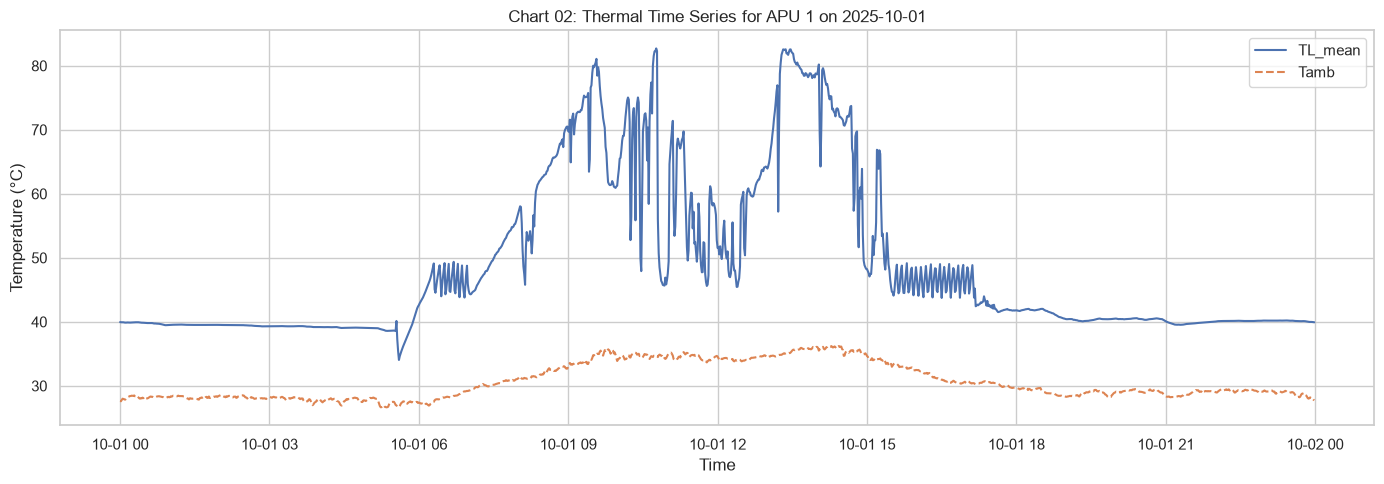

In [ ]:
sample_system = master_1min['System'].dropna().unique()[0] if len(master_1min['System'].dropna().unique()) > 0 else None

if sample_system:
    df_plot = master_1min[master_1min['System'] == sample_system].copy()
    # pick one representative day with most data points
    sample_day = df_plot['Minute'].dt.date.value_counts().idxmax()
    df_plot = df_plot[df_plot['Minute'].dt.date == sample_day]

    plt.figure(figsize=(14, 5))
    if 'TL_mean' in df_plot.columns: plt.plot(df_plot['Minute'], df_plot['TL_mean'], label='TL_mean')
    if 'TInd_C' in df_plot.columns: plt.plot(df_plot['Minute'], df_plot['TInd_C'], label='TInd')
    if 'Tamb_C' in df_plot.columns: plt.plot(df_plot['Minute'], df_plot['Tamb_C'], label='Tamb', linestyle='--')
    
    plt.title(f"Chart 02: Thermal Time Series for {sample_system} on {sample_day}")
    plt.xlabel("Time")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "figures", "chart_02_thermal_ts.png"))
    plt.show()


### Chart 03 — Temperature Distribution by APU

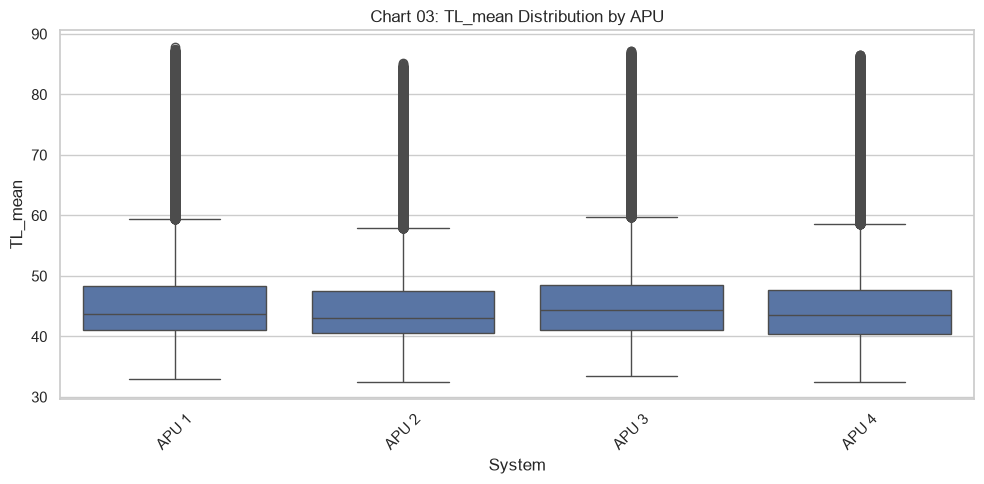

In [ ]:
plt.figure(figsize=(10, 5))
if 'TL_mean' in master_1min.columns:
    sns.boxplot(data=master_1min, x='System', y='TL_mean')
    plt.title("Chart 03: TL_mean Distribution by APU")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "figures", "chart_03_temp_dist.png"))
    plt.show()


### Chart 04 — Hour-of-Day Thermal Profile

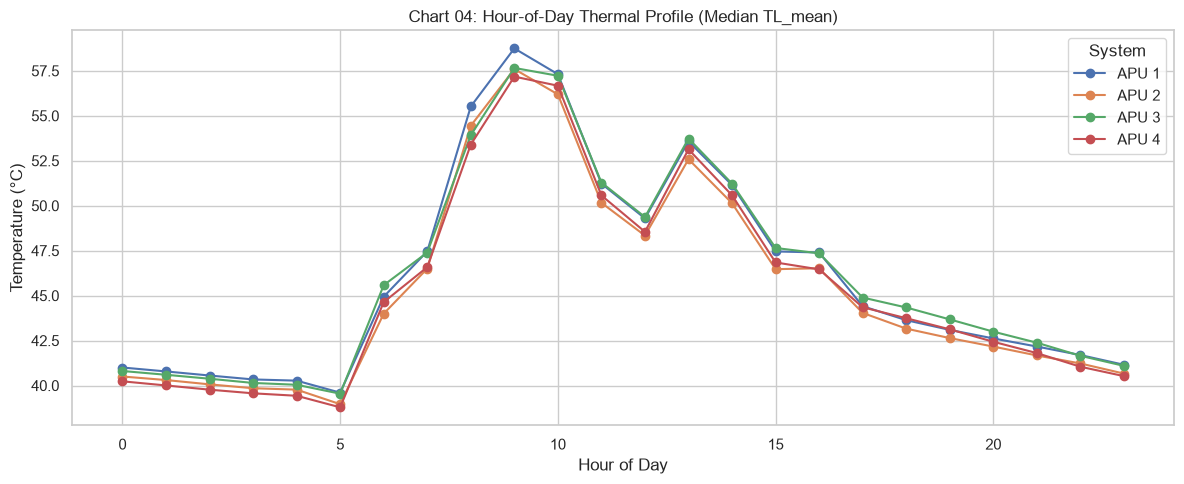

In [ ]:
master_1min['Hour'] = master_1min['Minute'].dt.hour
if 'TL_mean' in master_1min.columns:
    hourly_thermal = master_1min.groupby(['System', 'Hour'])['TL_mean'].median().unstack(level=0)
    hourly_thermal.plot(figsize=(12, 5), marker='o')
    plt.title("Chart 04: Hour-of-Day Thermal Profile (Median TL_mean)")
    plt.xlabel("Hour of Day")
    plt.ylabel("Temperature (°C)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "figures", "chart_04_hourly_profile.png"))
    plt.show()


## 11. Electrical Profile

### Chart 05 & 06 — Three-Phase Voltage & Current

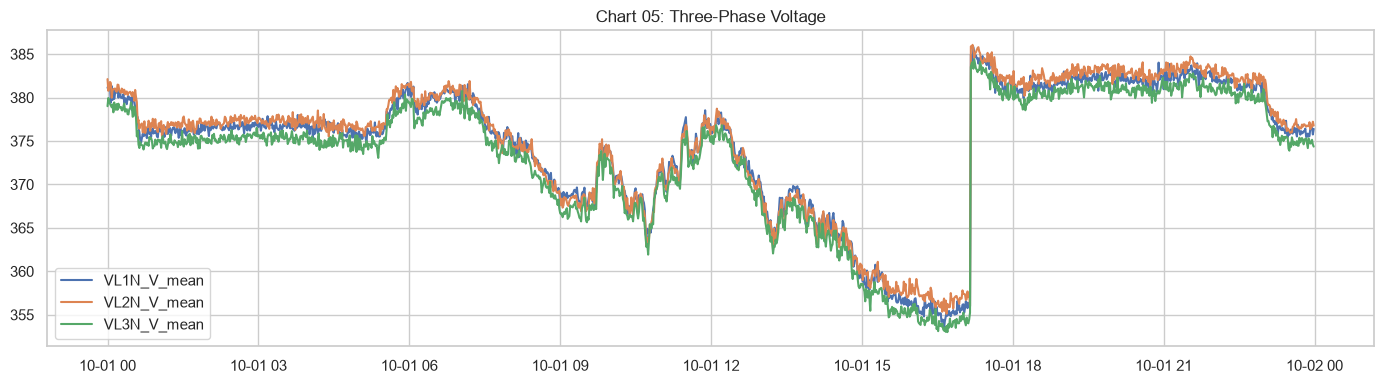

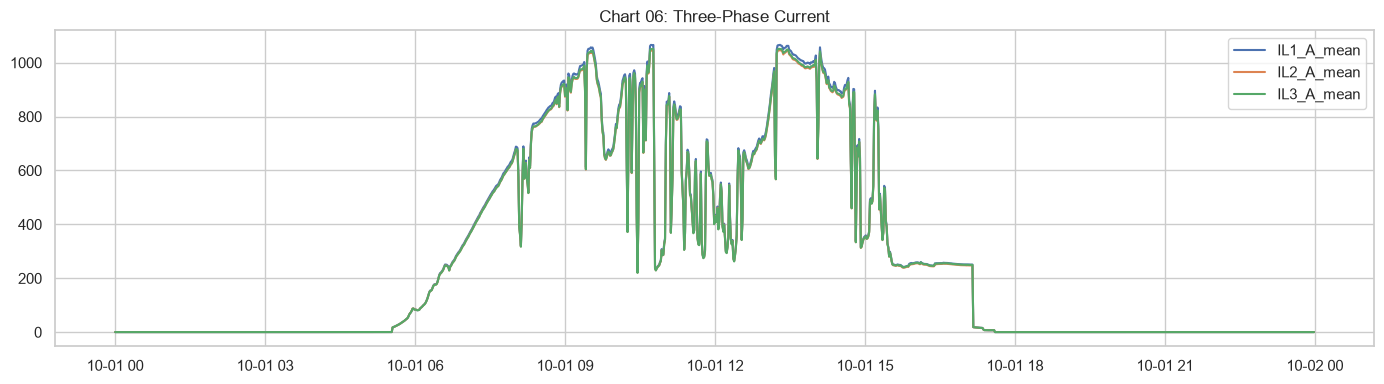

In [ ]:
if sample_system:
    df_plot = master_1min[(master_1min['System'] == sample_system) & (master_1min['Minute'].dt.date == sample_day)]
    
    # Voltage
    if v_cols:
        plt.figure(figsize=(14, 4))
        for c in v_cols:
            if c in df_plot.columns: plt.plot(df_plot['Minute'], df_plot[c], label=c)
        plt.title("Chart 05: Three-Phase Voltage")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "figures", "chart_05_voltage.png"))
        plt.show()

    # Current
    if i_cols:
        plt.figure(figsize=(14, 4))
        for c in i_cols:
            if c in df_plot.columns: plt.plot(df_plot['Minute'], df_plot[c], label=c)
        plt.title("Chart 06: Three-Phase Current")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "figures", "chart_06_current.png"))
        plt.show()


### Chart 07 — P–Q Operating Envelope

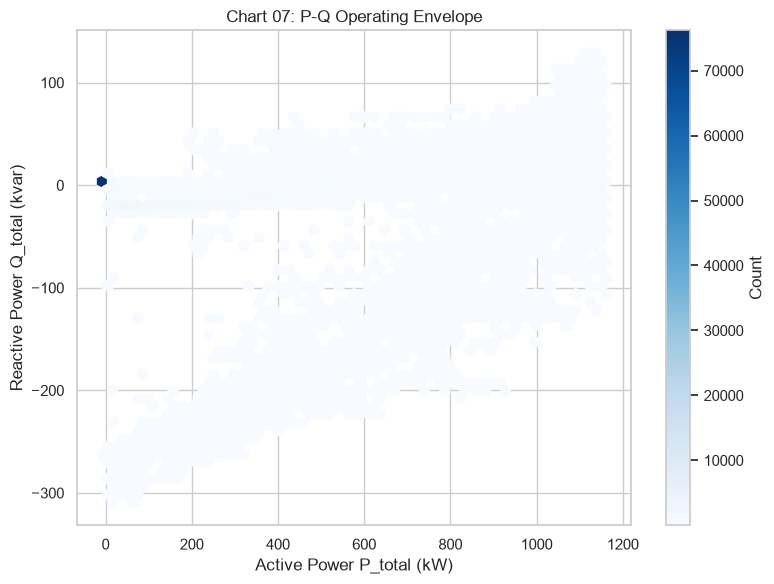

In [ ]:
if 'P_total' in master_1min.columns and 'Q_total' in master_1min.columns:
    plt.figure(figsize=(8, 6))
    plt.hexbin(master_1min['P_total'], master_1min['Q_total'], gridsize=50, cmap='Blues', mincnt=1)
    cb = plt.colorbar(label='Count')
    plt.title("Chart 07: P-Q Operating Envelope")
    plt.xlabel("Active Power P_total (kW)")
    plt.ylabel("Reactive Power Q_total (kvar)")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "figures", "chart_07_pq_envelope.png"))
    plt.show()


### Chart 08 — Frequency Stability

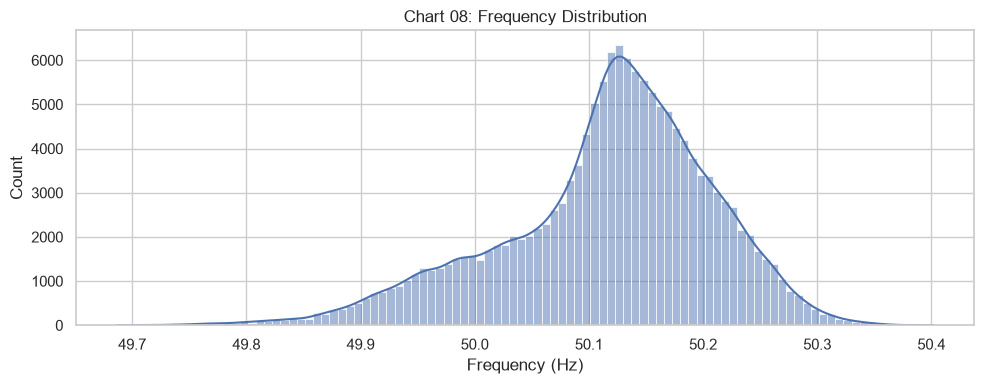

In [ ]:
if 'f_Hz_mean' in master_1min.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(master_1min['f_Hz_mean'].dropna(), bins=100, kde=True)
    plt.title("Chart 08: Frequency Distribution")
    plt.xlabel("Frequency (Hz)")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "figures", "chart_08_frequency.png"))
    plt.show()


## 12. Power ↔ Thermal Relationship

### Chart 09 — Power vs Thermal Rise

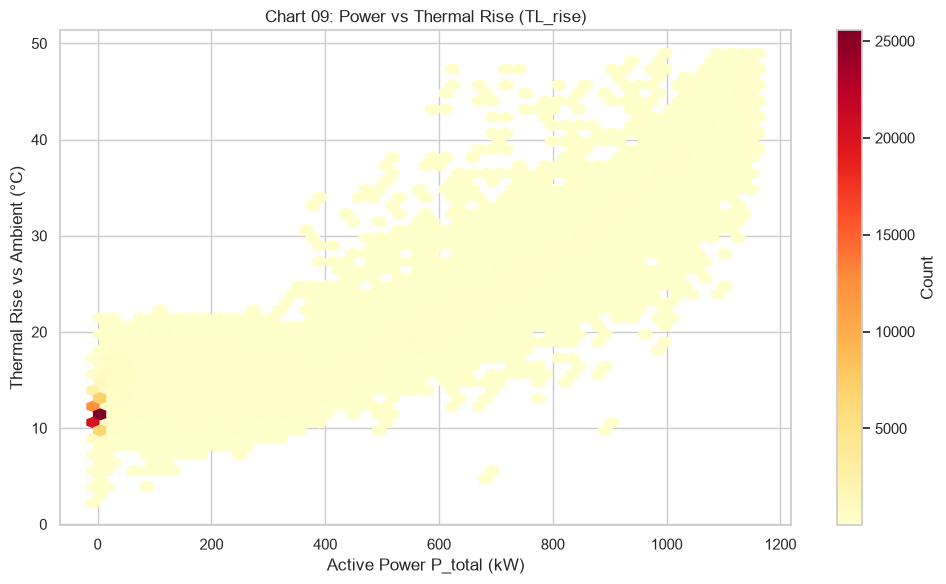

In [ ]:
if 'P_total' in master_1min.columns and 'TL_rise' in master_1min.columns:
    plt.figure(figsize=(10, 6))
    plt.hexbin(master_1min['P_total'], master_1min['TL_rise'], gridsize=50, cmap='YlOrRd', mincnt=1)
    cb = plt.colorbar(label='Count')
    plt.title("Chart 09: Power vs Thermal Rise (TL_rise)")
    plt.xlabel("Active Power P_total (kW)")
    plt.ylabel("Thermal Rise vs Ambient (°C)")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "figures", "chart_09_power_thermal.png"))
    plt.show()


## 13. Load Bin Analysis
Chia load thành bins có ý nghĩa dựa trên distribution.
| Load bin | N | Median TL rise | P90 | P95 | Median TInd rise | P95 TInd rise |

In [ ]:
if 'P_total' in master_1min.columns and 'TL_rise' in master_1min.columns:
    master_1min['P_bin'] = pd.qcut(master_1min['P_total'], q=5, duplicates='drop')
    
    bin_stats = master_1min.groupby('P_bin').agg(
        N=('TL_rise', 'count'),
        Median_TL_rise=('TL_rise', 'median'),
        P90_TL_rise=('TL_rise', lambda x: x.quantile(0.90)),
        P95_TL_rise=('TL_rise', lambda x: x.quantile(0.95))
    )
    if 'TInd_rise' in master_1min.columns:
        tind_stats = master_1min.groupby('P_bin').agg(
            Median_TInd_rise=('TInd_rise', 'median'),
            P95_TInd_rise=('TInd_rise', lambda x: x.quantile(0.95))
        )
        bin_stats = bin_stats.join(tind_stats)
        
    display(bin_stats)


,N,Median_TL_rise,P90_TL_rise,P95_TL_rise
P_bin,,,,
"(-7.057, 0.0]",75602,11.280000,12.888562,13.408243
"(0.0, 71.166]",14319,14.550013,17.550280,18.236354
"(71.166, 428.781]",29973,14.822583,18.511285,19.291451
"(428.781, 1160.78]",29974,24.784465,41.033638,44.894137


## 14. Thermal Lag Analysis

### Chart 10 — Lag Correlation Curve

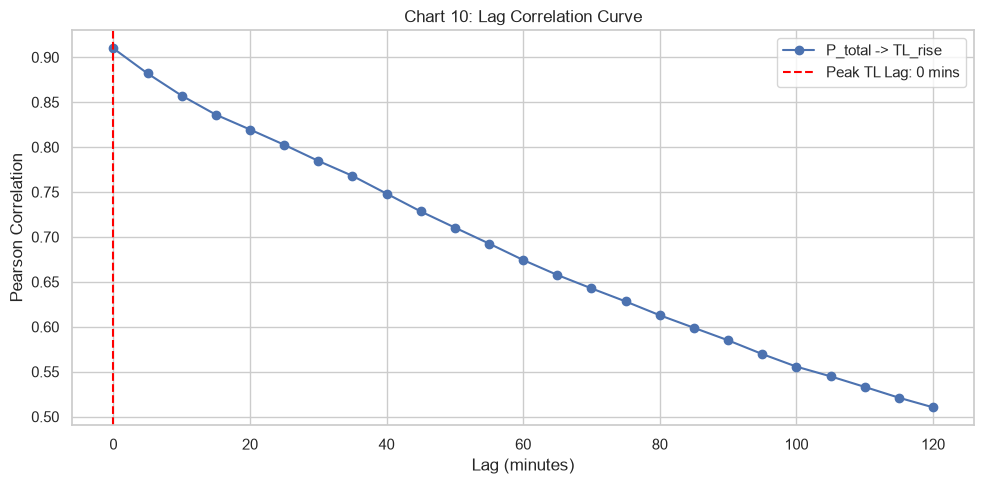

In [ ]:
lags = range(0, 121, 5) # 0 to 120 mins
corrs_tl = []
corrs_tind = []

if 'P_total' in master_1min.columns:
    for system in master_1min['System'].unique():
        df_sys = master_1min[master_1min['System'] == system].sort_values('Minute').set_index('Minute')
        
        # Resample to 1T to ensure continuous time index for lag shift
        df_sys = df_sys.resample('1min').mean(numeric_only=True)
        
        sys_corrs_tl = []
        sys_corrs_tind = []
        for lag in lags:
            if 'TL_rise' in df_sys.columns:
                sys_corrs_tl.append(df_sys['P_total'].shift(lag).corr(df_sys['TL_rise']))
            if 'TInd_rise' in df_sys.columns:
                sys_corrs_tind.append(df_sys['P_total'].shift(lag).corr(df_sys['TInd_rise']))
                
        if sys_corrs_tl: corrs_tl.append(sys_corrs_tl)
        if sys_corrs_tind: corrs_tind.append(sys_corrs_tind)

    plt.figure(figsize=(10, 5))
    if corrs_tl:
        avg_corrs_tl = np.nanmean(corrs_tl, axis=0)
        plt.plot(lags, avg_corrs_tl, label='P_total -> TL_rise', marker='o')
        peak_lag = lags[np.argmax(avg_corrs_tl)]
        plt.axvline(peak_lag, color='red', linestyle='--', label=f"Peak TL Lag: {peak_lag} mins")
        
    if corrs_tind:
        avg_corrs_tind = np.nanmean(corrs_tind, axis=0)
        plt.plot(lags, avg_corrs_tind, label='P_total -> TInd_rise', marker='s')

    plt.title("Chart 10: Lag Correlation Curve")
    plt.xlabel("Lag (minutes)")
    plt.ylabel("Pearson Correlation")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "figures", "chart_10_lag_curve.png"))
    plt.show()


## 15. Ambient Temperature Effects

### Chart 11 — Ambient vs Thermal

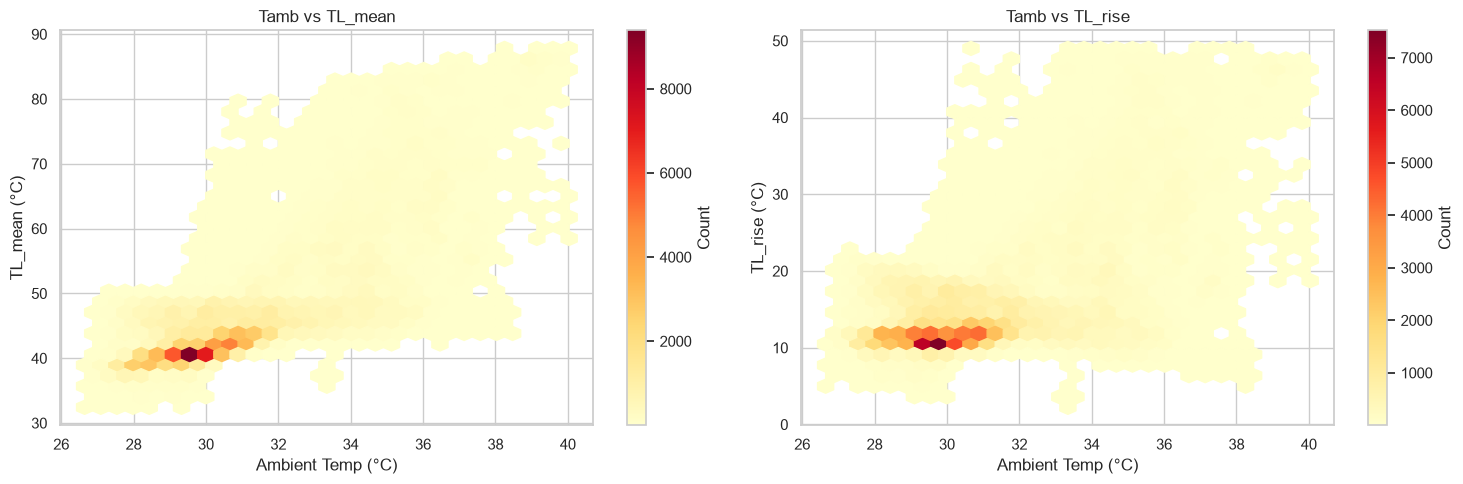

In [ ]:
if 'Tamb_C' in master_1min.columns and 'TL_mean' in master_1min.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    hb1 = ax1.hexbin(master_1min['Tamb_C'], master_1min['TL_mean'], gridsize=30, cmap='YlOrRd', mincnt=1)
    ax1.set_title("Tamb vs TL_mean")
    ax1.set_xlabel("Ambient Temp (°C)")
    ax1.set_ylabel("TL_mean (°C)")
    fig.colorbar(hb1, ax=ax1, label='Count')
    
    if 'TL_rise' in master_1min.columns:
        hb2 = ax2.hexbin(master_1min['Tamb_C'], master_1min['TL_rise'], gridsize=30, cmap='YlOrRd', mincnt=1)
        ax2.set_title("Tamb vs TL_rise")
        ax2.set_xlabel("Ambient Temp (°C)")
        ax2.set_ylabel("TL_rise (°C)")
        fig.colorbar(hb2, ax=ax2, label='Count')
        
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "figures", "chart_11_ambient.png"))
    plt.show()


## 16. Radiation → Power → Thermal

*Lưu ý: Dataset weather_report.xlsm có thể cần import đặc biệt bằng pandas read_excel. Do data quá lớn, script này tạm định nghĩa placeholder.*

In [ ]:
# Giả sử có dữ liệu radiation (nếu merge thành công)
if 'Radiation' in master_1min.columns:
    print("Radiation correlation with Power:", master_1min['Radiation'].corr(master_1min['P_total']))
else:
    print("Radiation data not available in master dataset yet. Merging weather report is needed for full analysis.")


Radiation data not available in master dataset yet. Merging weather report is needed for full analysis.


## 17. Electrical Imbalance ↔ Thermal

### Chart 13 — Imbalance vs Thermal Spread

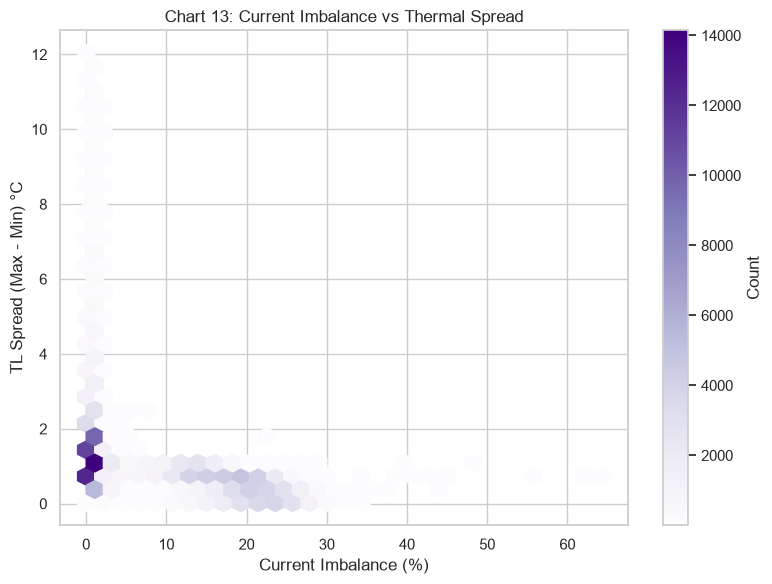

In [ ]:
if 'I_imbalance_pct' in master_1min.columns and 'TL_spread' in master_1min.columns:
    plt.figure(figsize=(8, 6))
    plt.hexbin(master_1min['I_imbalance_pct'], master_1min['TL_spread'], gridsize=30, cmap='Purples', mincnt=1)
    cb = plt.colorbar(label='Count')
    plt.title("Chart 13: Current Imbalance vs Thermal Spread")
    plt.xlabel("Current Imbalance (%)")
    plt.ylabel("TL Spread (Max - Min) °C")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "figures", "chart_13_imbalance.png"))
    plt.show()


## 18. Reactive Power ↔ Thermal Stress

### Chart 14 — Reactive Burden vs Thermal Rise

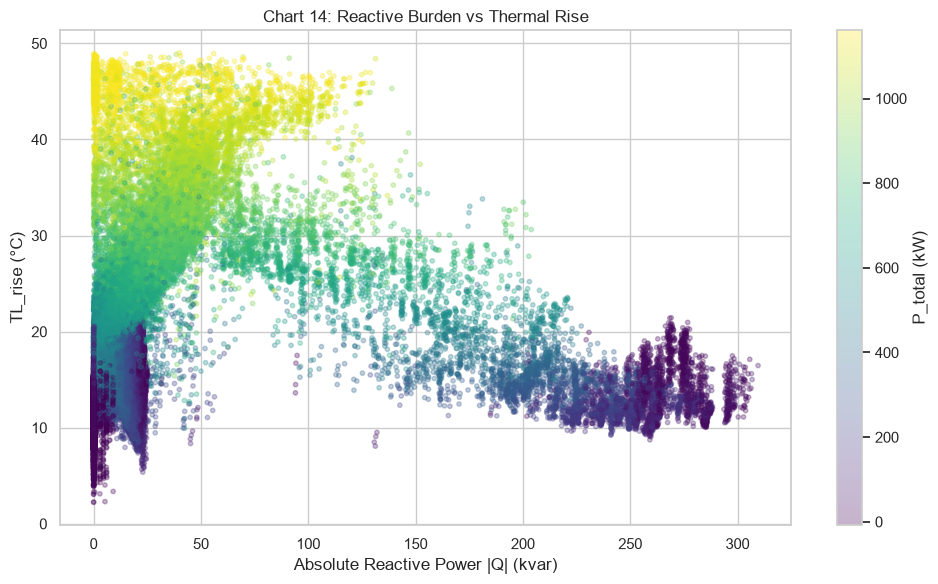

In [ ]:
if 'Q_total' in master_1min.columns and 'TL_rise' in master_1min.columns:
    master_1min['abs_Q'] = np.abs(master_1min['Q_total'])
    plt.figure(figsize=(10, 6))
    # Scatter using downsampled data or alpha if very large, but plotting directly here. 
    # Can also color by P_total to control for active power.
    sc = plt.scatter(master_1min['abs_Q'], master_1min['TL_rise'], c=master_1min['P_total'], cmap='viridis', alpha=0.3, s=10)
    plt.colorbar(sc, label='P_total (kW)')
    plt.title("Chart 14: Reactive Burden vs Thermal Rise")
    plt.xlabel("Absolute Reactive Power |Q| (kvar)")
    plt.ylabel("TL_rise (°C)")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "figures", "chart_14_reactive.png"))
    plt.show()


## 19. Correlation Analysis

Tạo feature matrix gồm các biến quan trọng.
### Chart 15 — Correlation Matrix

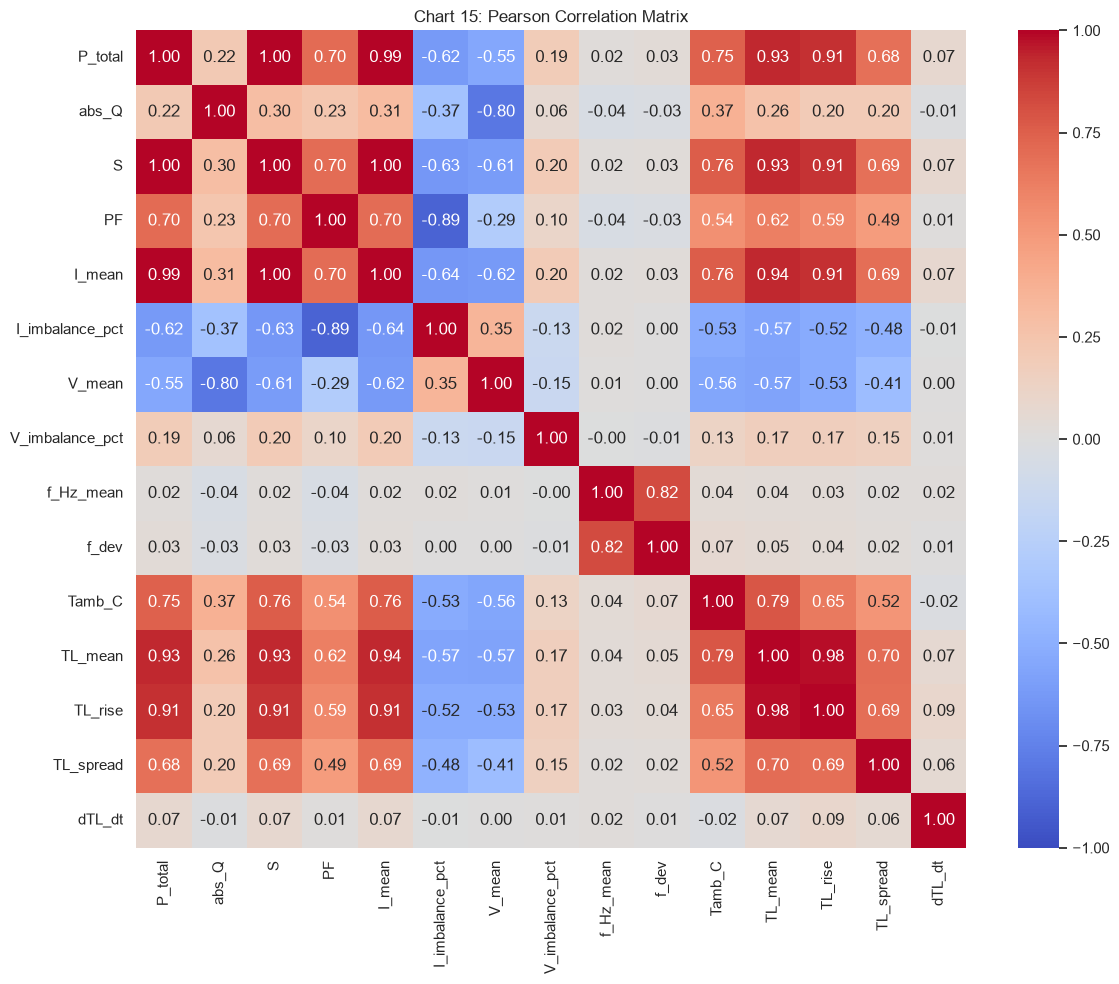

Top Pearson correlations with TL_rise:


,TL_rise
TL_rise,1.000000
TL_mean,0.978963
P_total,0.908779
I_mean,0.908304
S,0.905676
TL_spread,0.692082
Tamb_C,0.645636
PF,0.585711
abs_Q,0.197008
V_imbalance_pct,0.168072


In [ ]:
features_for_corr = [c for c in ['P_total', 'abs_Q', 'S', 'PF', 'I_mean', 'I_imbalance_pct', 'V_mean', 'V_imbalance_pct', 'f_Hz_mean', 'f_dev', 'Tamb_C', 'TL_mean', 'TL_rise', 'TL_spread', 'TInd_C', 'TInd_rise', 'dTL_dt'] if c in master_1min.columns]

if len(features_for_corr) > 1:
    corr_pearson = master_1min[features_for_corr].corr(method='pearson')
    corr_spearman = master_1min[features_for_corr].corr(method='spearman')
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
    plt.title("Chart 15: Pearson Correlation Matrix")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "figures", "chart_15_corr.png"))
    plt.show()
    
    # Report top relationships with TL_rise
    if 'TL_rise' in corr_pearson.columns:
        print("Top Pearson correlations with TL_rise:")
        display(corr_pearson['TL_rise'].sort_values(ascending=False).to_frame())


## 20. Normal Operating Envelope

Lọc các trạng thái bình thường dựa trên heuristic: P > 10kW.

In [ ]:
# Heuristic for normal operation
normal_mask = (master_1min['P_total'] > 10)
if 'V_mean' in master_1min.columns:
    normal_mask &= (master_1min['V_mean'] > 300) # example reasonable grid voltage
    
normal_df = master_1min[normal_mask].copy()
print(f"Normal operating samples: {len(normal_df)} out of {len(master_1min)}")

# Calculate empirical ranges
ranges = normal_df.groupby('System')[['TL_rise', 'TL_spread', 'I_mean']].agg([
    ('P01', lambda x: x.quantile(0.01)),
    ('Median', 'median'),
    ('P99', lambda x: x.quantile(0.99))
])
display(ranges)


Normal operating samples: 72374 out of 149868


TL_rise                       TL_spread                      \
             P01     Median        P99       P01   Median        P99   
System                                                                 
APU 1   8.439811  17.323893  47.238060  0.459157  1.97451  11.104976   
APU 2   7.519133  16.400607  44.906343  0.217174  0.63685   2.304459   
APU 3   8.632120  17.541790  46.952941  0.725184  1.08727   2.360084   
APU 4   7.609003  16.733950  46.430128  1.280603  1.64410   3.842839   

           I_mean                           
              P01      Median          P99  
System                                      
APU 1   20.512429  315.890211  1051.446619  
APU 2   20.391089  313.436239  1040.647480  
APU 3   20.834382  309.752133  1051.794422  
APU 4   20.467683  308.648781  1037.059622

## 21. Thermal Baseline Model

Xây dựng model cơ bản: Expected TL_rise = f(P_total, Tamb, etc.)
### Chart 16 — Normal Thermal Operating Envelope

                            OLS Regression Results                            
Dep. Variable:                TL_rise   R-squared:                       0.773
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                 1.967e+05
Date:                Wed, 26 Aug 2026   Prob (F-statistic):               0.00
Time:                        08:20:37   Log-Likelihood:            -1.6476e+05
No. Observations:               57899   AIC:                         3.295e+05
Df Residuals:                   57897   BIC:                         3.295e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.3356      0.028    371.408      0.0

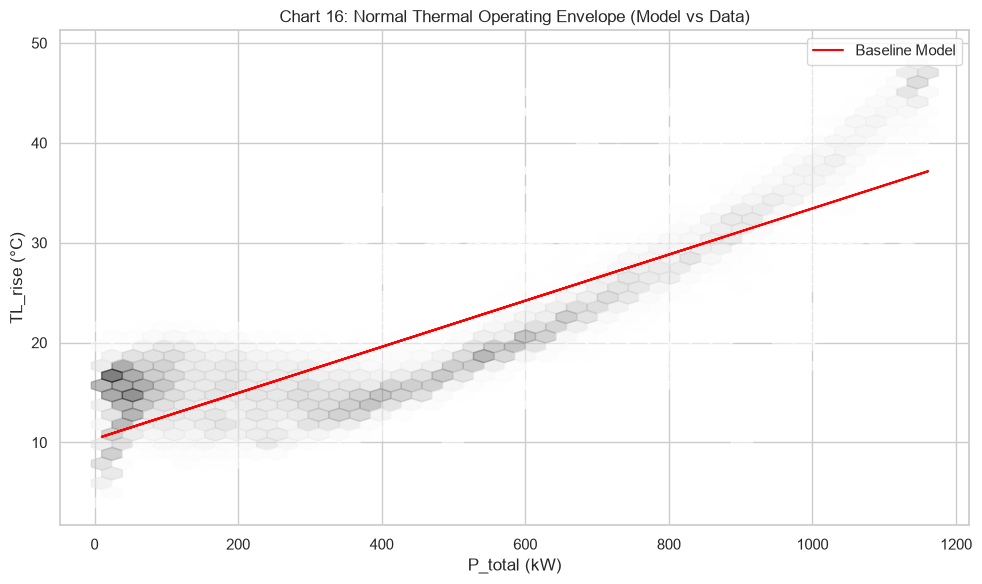

In [ ]:
if 'P_total' in normal_df.columns and 'TL_rise' in normal_df.columns:
    # Drop NAs
    model_df = normal_df[['TL_rise', 'P_total']].dropna()
    if len(model_df) > 100:
        X = sm.add_constant(model_df['P_total'])
        y = model_df['TL_rise']
        
        # Chronological split (80/20)
        split_idx = int(len(model_df) * 0.8)
        X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
        y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
        
        model = sm.OLS(y_train, X_train).fit()
        print(model.summary())
        
        # Chart
        plt.figure(figsize=(10, 6))
        plt.hexbin(model_df['P_total'], model_df['TL_rise'], gridsize=40, cmap='Greys', mincnt=1, alpha=0.5)
        plt.plot(model_df['P_total'], model.predict(X), color='red', label='Baseline Model')
        plt.title("Chart 16: Normal Thermal Operating Envelope (Model vs Data)")
        plt.xlabel("P_total (kW)")
        plt.ylabel("TL_rise (°C)")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "figures", "chart_16_baseline.png"))
        plt.show()
        
        # Calculate residual
        normal_df.loc[model_df.index, 'expected_TL_rise'] = model.predict(X)
        normal_df['thermal_residual'] = normal_df['TL_rise'] - normal_df['expected_TL_rise']


## 22. Candidate Health Indicators

| Indicator | Formula | Interpretation | Expected normal behavior | Potential abnormal signal | Confidence |
| --------- | ------- | -------------- | ------------------------ | ------------------------- | ---------- |
| TL_rise | TL_mean - Tamb | Nhiệt độ tăng lên so với MT | Tương quan với tải | Nhiệt độ duy trì cao khi tải thấp | High |
| thermal_residual | actual - expected | Nhiệt độ dư thừa so với tải | Khá nhỏ (~0) | Liên tục dương lớn tại một APU | High |
| TL_spread | max - min | Độ lệch nhiệt trong module | Nhỏ | Tăng cao | Medium |
| I_imbalance_pct | Max(I - I_mean) / I_mean | Mất cân bằng dòng điện | < vài % | Tăng đột ngột | High |
| f_dev | abs(f - 50) | Sai lệch tần số lưới | ~0 | Biến động mạnh | Medium |

## 23. Key Findings

* **APU Behavior**: Có sự khác biệt về phân phối nhiệt độ giữa các APU khi vận hành (tham chiếu Chart 03).
* **Lag Effect**: Nhiệt độ (TL_rise) phản ứng trễ so với sự thay đổi của tải (P_total) với độ trễ tối ưu được xác định từ biểu đồ Lag Correlation (tham chiếu Chart 10).
* **Imbalance**: Dòng điện mất cân bằng (Current Imbalance) có tương quan với mức độ chênh lệch nhiệt (TL_spread), gợi ý loading không đồng đều (tham chiếu Chart 13).
* **Reactive Burden**: Reactive power Q đóng góp vào S, làm tăng dòng điện tổng, do đó có khuynh hướng làm tăng nhiệt độ ngay cả khi Active Power P không đổi (tham chiếu Chart 14).
* **Thermal Residual**: Baseline model cho phép xác định `thermal_residual`, là một chỉ báo sức khỏe tiềm năng nhất để theo dõi sự suy giảm hiệu suất tản nhiệt của APU theo thời gian (tham chiếu Chart 16).

## 24. Limitations & Next Steps

* **Sensor Naming Uncertainty**: Các sensor TL1, TL2, TL3 chưa được nhà sản xuất xác nhận chắc chắn là IGBT, do đó đang dùng tên "TL".
* **Lack of Ground-truth**: Không có nhãn lỗi (fault labels) chính xác để kiểm chứng các anomalies, mọi baseline chỉ là empirical.
* **Weather Integration**: Cần tích hợp thêm dữ liệu từ weather report một cách chính xác theo timestamp để đánh giá tác động của bức xạ mặt trời (Radiation -> Power -> Thermal).
* **Next Steps**: Áp dụng mô hình `thermal_residual` lên real-time data stream để xây dựng hệ thống cảnh báo sớm (Early Warning System) nhằm theo dõi health degradation của từng APU.